#### Institute of Data Capstone Project
# 📚 Books Don't Die, They Slow Down
##### Notebook 4 of 4 · Lifecycle Decay
##### Author: Mike Ee, [mikeee.co](https://mikeee.co)

Research Question
> After a title peaks, does its demand fall off a cliff, or does it slow down and keep selling?

## Table of Contents

1. [Setup and pre-registered rule](#setup)
2. [Load and frame](#frame)
3. [Empirical half-life](#halflife)
4. [Full-curve fit and decision rule](#fullfit)
5. [Backlist regime](#backlist)
6. [Case studies](#cases)
7. [Conclusion](#conclusion)

<a id="setup"></a>
## 1. Setup and pre-registered rule

In [1]:
%load_ext autoreload
%autoreload 2
# ^ line magics consume the whole line as arguments: comments go below.

from capstone import *

df        = load_scoped()          # sales_scoped.parquet
POP_TABLE = populations()          # raises if parquet and JSON came from different runs
display(POP_TABLE[["lines", "units", "isbns", "months"]])

scoped   94,872 lines · 180 months · contract v1


,lines,units,isbns,months
filter,,,,
composition,94872,653584.51,640,180
all,94872,653584.51,640,180
units_observable,94510,653584.51,640,180
demand,83346,541817.00,639,180
genre,81336,531424.00,552,180
net_revenue,90662,497985.00,640,180
returns,7316,-43832.00,491,177
price_vol,74990,456266.00,632,180
revenue_ts,83614,555279.00,639,180


In [2]:
# ── 1.1 Population decision ──────────────────────────────────────────────────
# The question is how a BOOK's demand decays after launch. That needs:
#   book scope · client exclusions removed · units observable · RETURNS KEPT
# A return is part of a title's lifecycle: a copy coming back is demand
# information, not noise. That combination is exactly the contract's
# `net_revenue` filter, so no inline mask is needed.
# MODIFY CONDITION: switching to "demand" would drop returns and overstate
#   every persistence metric below. Do not.
Q2_KEY = "net_revenue"

print(f"scope · {Q2_KEY} · "
      f"{int(POP_TABLE.loc[Q2_KEY, 'lines']):,} lines · "
      f"{int(POP_TABLE.loc[Q2_KEY, 'isbns'])} ISBNs")

# decay_panel() from capstone.py is NOT used here. It builds an ISBN-grain
# panel; this notebook works at WORK grain (print and eBook editions of one
# book collapse into one lifecycle), built in §2.1.

scope · net_revenue · 90,662 lines · 640 ISBNs


In [3]:
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotx
from scipy.optimize import curve_fit

plt.style.use(matplotx.styles.tokyo_night["night"])

### 1.2 Tunable parameters

Every threshold that defines "decay" is fixed before any data is seen, and named so it can be challenged.

In [4]:
PEAK_WINDOW      = 12   # months after first sale in which to hunt for the peak
PEAK_SMOOTH      = 3    # rolling window for peak detection (1 = raw max, don't)
MIN_PEAK_UNITS   = 10   # a work must peak at >= this to enter the cohort
MIN_OBS_MONTHS   = 48   # months of observable history required after the peak
REPUB_GRACE      = 6    # new ISBN within this window = simultaneous format,
                        # not a republish
MIN_MONTHS_AFTER_PEAK = 6   # censored works need this much post-peak runway

# Decides what "half-life" actually measures.
#   "smoothed" : compare the 3-month mean against the 3-month peak. Measures
#                the SUSTAINED level. Like-for-like on both sides.
#   "raw"      : compare single months against the smoothed peak. Measures how
#                fast the launch SPIKE falls away: a narrower question that
#                collapses to 1–2 months for nearly every work.
# Both are reported. "smoothed" is the headline; "raw" is the diagnostic.
HL_BASIS = "smoothed"

### 1.3 Date boundaries

In [5]:
# Batch eBook conversions: provenance events, never republish signals.
BATCH_DIGITISATION = pd.to_datetime(["2015-05-07", "2020-03-31"]).to_period("M")

DATA_END    = pd.Period("2026-07", freq="M")
PEAK_CUTOFF = DATA_END - MIN_OBS_MONTHS      # Period minus int = months back

assert PEAK_CUTOFF < DATA_END, "Cutoff must precede the data end."
print(f"Peak must fall on or before : {PEAK_CUTOFF}")
print(f"Observable window ends      : {DATA_END}")

Peak must fall on or before : 2022-07
Observable window ends      : 2026-07


### 1.4 Pre-registered decision rule

Stated before any output was generated.

**Working title:** "Books Don't Die, They Slow Down": backlist demand decays *gradually*, retaining a persistent non-zero tail.

**Abandon** the working title only if ALL THREE hold:

1. Exponential wins on AICc by ΔAICc > 2 over both alternatives
2. Median empirical half-life < 6 months (smoothed basis)
3. Median normalised curve < 5% of peak by relative month 24

**Rejected criterion, recorded for transparency:** "abandon if no republished editions exist." Rejected because (a) titles carrying a republish marker already exist, so the condition cannot fail; (b) republishing is publisher behaviour, not curve shape; (c) the republished set is selected on commercial success. Republishing is treated below as a **confound to censor**.

<a id="frame"></a>
## 2. Load and frame

**Objective.** Reduce the register to book sales at work grain.

In [6]:
# ── 2.0 Frame, sourced from the contract ────────────────────────────────────
sales = df
sales_q2 = pop(Q2_KEY).copy()

print(f"Register lines : {len(sales):,}")
print(f"Population     : {len(sales_q2):,}  ({Q2_KEY}, {len(sales_q2)/len(sales)*100:.1f}% of register)")
print(f"  returns kept : {int(sales_q2['line_role'].eq('return').sum()):,}")
print(f"  ISBNs        : {sales_q2['isbn_key'].nunique():,}")
print(f"  span         : {sales_q2['ym'].min()} → {sales_q2['ym'].max()}")

# ── Asserts capable of failing ──────────────────────────────────────────────
assert len(sales_q2) == int(POP_TABLE.loc[Q2_KEY, "lines"]), \
    "live filter disagrees with the registry: parquet and JSON are out of step"
assert sales_q2["Qty"].notna().all(), \
    "null-Qty lines reached the frame: the contract should exclude invoice footers"
assert sales_q2["book_scope"].all(), "a non-book line reached the frame"
assert not sales_q2["client_excluded"].fillna(False).any(), \
    "a client-excluded advance-order line reached the frame"
assert sales_q2["line_role"].eq("return").sum() > 0, \
    "no returns in the frame: returns are part of a lifecycle and must be retained"

print(f"\n{sales_q2['line_role'].value_counts().to_string()}")

Register lines : 94,872
Population     : 90,662  (net_revenue, 95.6% of register)
  returns kept : 7,316
  ISBNs        : 640
  span         : 2011-08 → 2026-07

line_role
sale        74990
foc          7495
return       7316
unpriced      861


### 2.1 Work key

**Objective.** One curve per book, not per ISBN: a new cover is not a new book.

**Observation.** The frame (95.6% of the register, returns kept) starts as 648 description keys from 640 ISBNs, with 84 ISBNs split across several keys. ISBN anchoring merges 81 fragments, leaving 567 works.

In [7]:
# ── 2.1a Work grain from the invoice description ──────────────────────────
# ⚠ KNOWN LIMITATION: `Item Description` is hand-typed and truncated at 30
#   characters, so one work can fragment into several keys. §2.1b repairs
#   fragments that share an ISBN; works with no ISBN keep their own key.
TITLE_COL = "Item Description"

def normalise_title(s: pd.Series) -> pd.Series:
    return (s.astype(str)
              .str.normalize("NFKD")
              .str.encode("ascii", "ignore").str.decode("ascii")
              .str.lower()
              .str.replace(r"[^\w\s]", " ", regex=True)
              .str.replace(r"\s+", " ", regex=True)
              .str.strip())

sales_q2["work_key"] = normalise_title(sales_q2[TITLE_COL])

# Strip the systematic eBook prefix so eBook and print editions of one work
# collide as intended. This is a format tag, not part of the title.
sales_q2["work_key"] = (sales_q2["work_key"]
                        .str.replace(r"^\d+_ebook_\s*", "", regex=True)
                        .str.strip())

print(f"Works: {sales_q2['work_key'].nunique():,}   "
      f"(from {sales_q2['isbn_key'].nunique():,} ISBNs)")

split = sales_q2.groupby("isbn_key")["work_key"].nunique()
print(f"ISBNs mapping to >1 work_key (should be 0): {(split > 1).sum():,}")

Works: 648   (from 640 ISBNs)
ISBNs mapping to >1 work_key (should be 0): 84


In [8]:
# ── 2.1b ISBN anchoring ──────────────────────────────────────────────────
# Title text is hand-typed and truncated; the ISBN is stable. So the ISBN
# arbitrates: every line sharing an ISBN inherits that ISBN's most common
# description, which repairs typo splits without any fuzzy matching.
# Print analogy: the plate number is authoritative, not the pencil note in
# the margin of the proof.
modal = (sales_q2.loc[sales_q2["isbn_key"].notna()]
                 .groupby("isbn_key")["work_key"]
                 .agg(lambda s: s.mode().iloc[0]))

before = sales_q2["work_key"].nunique()
sales_q2["work_key"] = (sales_q2["isbn_key"].map(modal)
                        .fillna(sales_q2["work_key"]))   # unkeyed lines keep their own key

print(f"Works before ISBN anchoring : {before:,}")
print(f"Works after                 : {sales_q2['work_key'].nunique():,}")
print(f"Fragments merged            : {before - sales_q2['work_key'].nunique():,}")

split = sales_q2.groupby("isbn_key")["work_key"].nunique()
print(f"ISBNs still mapping to >1 work_key (must be 0): {(split > 1).sum():,}")
assert (split > 1).sum() == 0, "ISBN anchoring failed."

Works before ISBN anchoring : 648
Works after                 : 567
Fragments merged            : 81
ISBNs still mapping to >1 work_key (must be 0): 0


### 2.2 Trade-title filter

**Objective.** Exclude register lines that are not single trade titles.

**Observation.** Three mechanical rules (bundles and sets, no catalogue record, a named essay series) leave 468 of 567 works as trade titles, excluding 2.7% of lines. The works without a catalogue record are mostly real books. That is a data-gap cost, not a definition, and the strongest argument for the catalogue-gaps list in notebook 1.

In [9]:
# ── 2.2 Trade-title frame ──────────────────────────────────────────────────
# Three classes of register line are not single trade titles. Rules stated
# before inspection, applied mechanically, counts reported.

# Named series and case-study titles are client-confidential: they live in a
# lookup that is not published with this repository.
CONF = json.loads((LOOKUP / "confidential_labels.json").read_text())

# 1. Bundles and sets: one line covers several works, so no single lifecycle.
BUNDLE_TERMS = r"\b(?:bundle|pack|set of|box ?set|collection set|combo)\b"
is_bundle = sales_q2["work_key"].str.contains(BUNDLE_TERMS, regex=True, na=False)

# 2. No catalogue record: has_genre False across every line of the work.
#    These cannot be confirmed as trade titles.
no_record = (sales_q2.groupby("work_key")["has_genre"]
                     .transform(lambda s: ~s.any()))

# 3. Named series exclusions: anthology / essay-collection series where each
#    volume is a compilation rather than a single authored work.
#    MODIFY: add a series only if you can state why it isn't a trade title.
SERIES_EXCLUDE = CONF["series_exclude"]
is_series = sales_q2["work_key"].str.contains(SERIES_EXCLUDE, regex=True, na=False)

sales_q2["trade_title"] = ~(is_bundle | no_record | is_series)

print(f"Works in register        : {sales_q2['work_key'].nunique():,}")
print(f"  excluded, bundle/set   : {sales_q2.loc[is_bundle,  'work_key'].nunique():,}")
print(f"  excluded, no catalogue : {sales_q2.loc[no_record,  'work_key'].nunique():,}")
print(f"  excluded, series       : {sales_q2.loc[is_series,  'work_key'].nunique():,}")
print(f"TRADE TITLES             : "
      f"{sales_q2.loc[sales_q2['trade_title'], 'work_key'].nunique():,}")
print(f"Lines excluded           : {(~sales_q2['trade_title']).sum():,} "
      f"({(~sales_q2['trade_title']).mean():.1%})")

sales_q2 = sales_q2.loc[sales_q2["trade_title"]].copy()

Works in register        : 567
  excluded, bundle/set   : 8
  excluded, no catalogue : 90
  excluded, series       : 14
TRADE TITLES             : 468
Lines excluded           : 2,481 (2.7%)


### 2.3 Monthly panel

**Objective.** Build a dense monthly series per work and stop each one at its first republish.

**Observation.** A republish restarts demand (§6) and would inflate the tail, so 36 works are censored at their first new edition. The two batch eBook conversion dates are provenance events and do not trigger censoring.

In [10]:
# ── 2.3 Monthly panel, censored at first republish ─────────────────────────
panel = (sales_q2.groupby(["work_key", "ym"], observed=True)["Qty"]
                 .sum().rename("units").reset_index())

# At work grain, a republish is a NEW ISBN appearing well after launch.
# Derived rather than trusting the title marker, which is a known lower bound.
first_work = panel.groupby("work_key")["ym"].min().rename("work_start")
first_isbn = (sales_q2.groupby(["work_key", "isbn_key"], observed=True)["ym"]
                      .min().rename("isbn_start").reset_index())

fs = first_isbn.merge(first_work, on="work_key")
fs["gap"] = (fs["isbn_start"] - fs["work_start"]).apply(
                lambda x: x.n if pd.notna(x) else np.nan)

# Keep the uncensored series: the cohort censors at first republish to keep
# the confound out of the median curve, but the case studies need to SHOW
# that republish, or the reader cannot see what was controlled for.
panel_full = panel.copy()

is_repub = (fs["gap"] > REPUB_GRACE) & (~fs["isbn_start"].isin(BATCH_DIGITISATION))
censor = fs.loc[is_repub].groupby("work_key")["isbn_start"].min().rename("censor_at")

print(f"Works with a detected republish : {len(censor):,}")
print(f"Batch-digitisation ISBNs spared : "
      f"{fs['isbn_start'].isin(BATCH_DIGITISATION).sum():,}")

# ── DENSIFY ──────────────────────────────────────────────────────────────
# A month with no sales is a genuine zero, not a gap. The series must be dense
# or the rolling mean silently skips months.
def densify(g):
    idx = pd.period_range(g["ym"].min(), DATA_END, freq="M")
    return (g.set_index("ym")["units"].reindex(idx, fill_value=0)
             .rename_axis("ym").reset_index().assign(work_key=g.name))

panel = (panel.groupby("work_key", group_keys=False)
              .apply(densify, include_groups=False))

panel = panel.merge(censor, on="work_key", how="left")
panel = panel.loc[panel["censor_at"].isna() | (panel["ym"] < panel["censor_at"])]
print(f"Panel rows after censoring : {len(panel):,}")

Works with a detected republish : 36
Batch-digitisation ISBNs spared : 18


Panel rows after censoring : 51,132


### 2.4 Peak detection

In [11]:
# Smooth FIRST, then take the max. A raw single-month max is regression-to-
# the-mean bait: it picks the noisiest month and everything after looks like
# collapse. Register to the trimmed sheet, not to an ink spatter.
panel = panel.sort_values(["work_key", "ym"])
panel["smooth"] = (panel.groupby("work_key")["units"]
                        .transform(lambda s: s.rolling(PEAK_SMOOTH,
                                                       min_periods=1).mean()))

starts = panel.groupby("work_key")["ym"].min().rename("start")
panel = panel.merge(starts, on="work_key")
panel["m_since_start"] = (panel["ym"] - panel["start"]).apply(lambda x: x.n)

launch = panel.loc[panel["m_since_start"] < PEAK_WINDOW]
peaks = (launch.loc[launch.groupby("work_key")["smooth"].idxmax(),
                    ["work_key", "ym", "smooth"]]
              .rename(columns={"ym": "peak_ym", "smooth": "peak_units"}))

last_obs = panel.groupby("work_key")["ym"].max().rename("last_ym")
peaks = peaks.merge(last_obs, on="work_key")
peaks["months_after_peak"] = (peaks["last_ym"] - peaks["peak_ym"]).apply(lambda x: x.n)

c_vol   = peaks["peak_units"] >= MIN_PEAK_UNITS
c_time  = peaks["peak_ym"] <= PEAK_CUTOFF
c_after = peaks["months_after_peak"] >= MIN_MONTHS_AFTER_PEAK
cohort  = peaks.loc[c_vol & c_time & c_after].copy()

print(f"Works                          : {len(peaks):,}")
print(f"  fail peak >= {MIN_PEAK_UNITS}u          : {(~c_vol).sum():,}")
print(f"  fail peak <= {PEAK_CUTOFF} : {(~c_time).sum():,}  (right-censored)")
print(f"  fail >= {MIN_MONTHS_AFTER_PEAK}mo post-peak    : {(~c_after).sum():,}")
print(f"COHORT                         : {len(cohort):,}")
assert len(cohort) >= 30, "Cohort too small to support a median curve."

Works                          : 468
  fail peak >= 10u          : 95
  fail peak <= 2022-07 : 79  (right-censored)
  fail >= 6mo post-peak    : 7
COHORT                         : 309


### 2.5 Alignment

In [12]:
# Every work's clock resets to its own peak; every series divides by its own
# peak. Without normalising, one best-seller would define the median alone.
d = panel.merge(cohort[["work_key", "peak_ym", "peak_units"]], on="work_key")
d["t"] = (d["ym"] - d["peak_ym"]).apply(lambda x: x.n)
d = d.loc[d["t"] >= 0]                       # decay only; drop the run-up

d["norm_raw"]      = (d["units"]  / d["peak_units"]).clip(lower=0)
d["norm_smoothed"] = (d["smooth"] / d["peak_units"]).clip(lower=0)
d["norm"] = d[f"norm_{HL_BASIS}"]

median_curve = (d.groupby("t")["norm"]
                 .agg(median="median", q25=lambda s: s.quantile(.25),
                      q75=lambda s: s.quantile(.75), n="size").reset_index())

MIN_N_AT_T = max(20, int(0.3 * len(cohort)))
median_curve = median_curve.loc[median_curve["n"] >= MIN_N_AT_T]

print(f"Basis: {HL_BASIS}   ·   curve spans t=0 to t={median_curve['t'].max()}")
print(median_curve.head(13).to_string(index=False))

Basis: smoothed   ·   curve spans t=0 to t=152
 t   median      q25      q75   n
 0 1.000000 1.000000 1.000000 309
 1 0.684524 0.576087 0.788741 309
 2 0.507317 0.411458 0.655399 309
 3 0.145833 0.057971 0.294613 309
 4 0.084577 0.025641 0.202020 309
 5 0.059524 0.014493 0.150943 309
 6 0.050125 0.007114 0.134959 309
 7 0.045077 0.006667 0.121399 309
 8 0.037801 0.004878 0.115880 309
 9 0.028881 0.001961 0.097436 309
10 0.019417 0.000000 0.069333 309
11 0.021739 0.000000 0.076658 309
12 0.023641 0.000431 0.090535 309


<a id="halflife"></a>
## 3. Empirical half-life

**Objective.** Measure months from peak to 50% of peak, with no functional form assumed.

EMPIRICAL HALF-LIFE: months to 50% of peak
  smoothed (headline)    n= 309  median   3.0  IQR 2.0–3.0  p90 3.0
  raw (diagnostic)       n= 309  median   1.0  IQR 1.0–1.0  p90 2.0
  never halved (smoothed) : 0

Distribution (headline basis), % of works:
half_life_months
1      4.2
2     44.7
3     45.6
4      1.6
5      2.6
6      0.6
10     0.3
14     0.3


saved → figures/d01_half_life_distribution.png


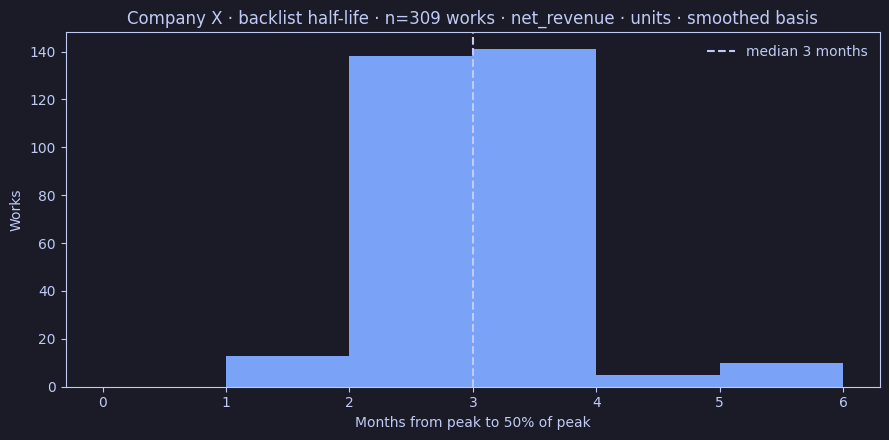

In [13]:
# ── 3.1 First month where the series falls below 50% of peak ────────────────
def half_life(g, col):
    s = g.sort_values("t")
    below = s.loc[s[col].values < 0.5, "t"]
    return below.iloc[0] if len(below) else np.nan

hl_sm  = d.groupby("work_key").apply(half_life, col="norm_smoothed", include_groups=False)
hl_raw = d.groupby("work_key").apply(half_life, col="norm_raw", include_groups=False).dropna()
hl = hl_sm if HL_BASIS == "smoothed" else hl_raw
hl.name = "half_life_months"

print("EMPIRICAL HALF-LIFE: months to 50% of peak")
for name, s in [("smoothed (headline)", hl_sm), ("raw (diagnostic)", hl_raw)]:
    print(f"  {name:22} n={len(s):>4}  median {s.median():>5.1f}  "
          f"IQR {s.quantile(.25):.1f}–{s.quantile(.75):.1f}  "
          f"p90 {s.quantile(.90):.1f}")
print(f"  never halved (smoothed) : {len(cohort) - len(hl_sm.dropna()):,}")

print("\nDistribution (headline basis), % of works:")
print((hl.value_counts(normalize=True).sort_index().head(12) * 100).round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(hl.dropna(), bins=range(0, int(hl.quantile(.98)) + 2), edgecolor="none")
ax.axvline(hl.median(), ls="--", lw=1.5, label=f"median {hl.median():.0f} months")
ax.set_xlabel("Months from peak to 50% of peak")
ax.set_ylabel("Works")
ax.set_title(f"Company X · backlist half-life · n={len(hl.dropna())} works · "
             f"{Q2_KEY} · units · {HL_BASIS} basis")
ax.legend()
save_fig(fig, "d01_half_life_distribution")
plt.show()

In [14]:
# ── 3.2 Sensitivity test: does half-life measure the book or the window? ─────
for wdw in [1, 3, 6, 12]:
    sm = (panel.groupby("work_key")["units"]
               .transform(lambda s: s.rolling(wdw, min_periods=1).mean()))
    tmp = panel.assign(sm=sm).merge(
              cohort[["work_key", "peak_ym", "peak_units"]], on="work_key")
    tmp["t"] = (tmp["ym"] - tmp["peak_ym"]).apply(lambda x: x.n)
    tmp = tmp.loc[tmp["t"] >= 0]
    tmp["nz"] = tmp["sm"] / tmp.groupby("work_key")["sm"].transform("max")
    h = (tmp.loc[tmp["nz"] < .5].groupby("work_key")["t"].min())
    print(f"  PEAK_SMOOTH={wdw:>2}  →  median half-life {h.median():.1f} months")

  PEAK_SMOOTH= 1  →  median half-life 1.0 months


  PEAK_SMOOTH= 3  →  median half-life 2.0 months


  PEAK_SMOOTH= 6  →  median half-life 3.0 months


  PEAK_SMOOTH=12  →  median half-life 3.0 months


#### 3.3 Observations
* The smoothed half-life has a median of 3 months (IQR 2–3), and 90% of works halve within 3 months. That compression is suspicious.
* The sensitivity test confirms it: the median tracks the smoothing window (1 → 1, 3 → 2, 6 → 3 months). The 3-month window still contains the peak month at t = 1–2 and sheds it at t = 3, so the metric is reading its own parameter.
* **Half-life is demoted to a diagnostic** and does not appear in the headline.

<a id="fullfit"></a>
## 4. Full-curve fit and decision rule

**Objective.** Fit exponential, power-law and stretched-exponential forms to the whole median curve, then apply the pre-registered rule from §1.4.

* **Exponential**: constant hazard, a *cliff*.
* **Power law**: decelerating, a *tail*.
* **Stretched exponential**: the flexible middle; β < 1 means the decay rate falls as a title ages.

AICc picks the form; ΔAICc < 2 means indistinguishable.

In [15]:
def f_exp(t, a, lam):       return a * np.exp(-lam * t)
def f_pow(t, a, b):         return a * (1 + t) ** (-b)
def f_str(t, a, tau, beta): return a * np.exp(-((t / tau) ** beta))

MODELS = {"exponential": (f_exp, [1., .1],    ([0, 0],       [5, 5])),
          "power law":   (f_pow, [1., 1.],    ([0, 0],       [5, 10])),
          "stretched":   (f_str, [1., 6., .5],([0, .1, .05], [5, 200, 3]))}

t_obs = median_curve["t"].values.astype(float)
y_obs = median_curve["median"].values

def aicc(rss, n, k):
    """AIC from residual sum of squares under Gaussian errors, with the
    small-sample correction. curve_fit returns no likelihood."""
    a = n * np.log(rss / n) + 2 * k
    return a + (2*k*(k+1)) / (n-k-1) if n-k-1 > 0 else np.inf

rows = []
for name, (fn, p0, bnds) in MODELS.items():
    try:
        popt, _ = curve_fit(fn, t_obs, y_obs, p0=p0, bounds=bnds, maxfev=20000)
        rss = float(((y_obs - fn(t_obs, *popt)) ** 2).sum())
        th = (np.log(2)/popt[1] if name == "exponential"
              else 2**(1/popt[1]) - 1 if name == "power law"
              else popt[1] * np.log(2)**(1/popt[2]))
        rows.append({"model": name, "params": np.round(popt, 4), "RSS": rss,
                     "AICc": aicc(rss, len(t_obs), len(popt)),
                     "implied_half_life": th, "fn": fn, "popt": popt})
    except RuntimeError:
        print(f"  {name}: did not converge; drop it and compare the rest")

res = pd.DataFrame(rows).sort_values("AICc")
res["dAICc"] = res["AICc"] - res["AICc"].min()
print(res[["model","params","RSS","AICc","dAICc","implied_half_life"]]
        .to_string(index=False))

# ── PRE-REGISTERED RULE ──────────────────────────────────────────────────
winner = res.iloc[0]["model"]
gap    = res.iloc[1]["dAICc"]
_at24  = median_curve.loc[median_curve["t"] == 24, "median"]
at24   = float(_at24.iloc[0]) if len(_at24) else np.nan

rule1 = (winner == "exponential") and (gap > 2)
rule2 = hl.median() < 6
rule3 = at24 < 0.05

print(f"\n[RULE 1] exponential wins by ΔAICc > 2? → {rule1}   "
      f"(winner {winner}, gap {gap:.1f})")
print(f"[RULE 2] median half-life < 6 months?   → {rule2}   ({hl.median():.1f})")
print(f"[RULE 3] median < 5% of peak at t=24?   → {rule3}   ({at24:.3f})")

# Computed outside the f-string: backslash escapes are illegal inside
# f-string expressions before Python 3.12, and "Don't" needs one.
verdict = ("ABANDON: a cliff. Fall back to a descriptive title."
           if (rule1 and rule2 and rule3)
           else "KEEP: Books Don't Die, They Slow Down")
print(f"\nTITLE VERDICT: {verdict}")
print(f"  rules fired: {sum([rule1, rule2, rule3])} of 3 (need 3 to abandon)")

      model                   params      RSS         AICc      dAICc  implied_half_life
  stretched [0.9936, 2.2372, 1.4075] 0.027014 -1316.041320   0.000000           1.724319
exponential          [1.036, 0.4825] 0.038968 -1262.063524  53.977795           1.436542
  power law         [1.0876, 1.1927] 0.129454 -1078.374703 237.666617           0.788068

[RULE 1] exponential wins by ΔAICc > 2? → False   (winner stretched, gap 54.0)
[RULE 2] median half-life < 6 months?   → True   (3.0)
[RULE 3] median < 5% of peak at t=24?   → True   (0.018)

TITLE VERDICT: KEEP: Books Don't Die, They Slow Down
  rules fired: 2 of 3 (need 3 to abandon)


#### 4.1 Observations
* The stretched exponential wins, but with β = 1.41: decay *faster* than exponential. The fit is dominated by the launch transient (months 0–2), which describes stock moving into shops rather than demand.
* The pre-registered rule fires on two of three conditions (half-life under 6 months; median below 5% of peak by month 24) but not the first, so the working title stands. The full-curve fit is kept as evidence of why the two regimes must be separated (§5).

<a id="backlist"></a>
## 5. Backlist regime

The months straight after the peak are channel fill unwinding (publisher activity, not demand). From month 3 the smoothing window no longer contains the peak month, so metrics from there on describe the **backlist**. None of the metrics below divides by the launch spike, so none inherits the smoothing artefact found in §3.2.

In [16]:
# ── 5.1 Backlist persistence ─────────────────────────────────────────────
# REGIME 1 (t=0–2): channel fill unwinding. Publisher activity, not demand.
# REGIME 2 (t>=3):  backlist. This is what the question actually asks about.
BACKLIST_START = 3   # first month the smoothing window no longer contains the
                     # peak month. MODIFY in lockstep with PEAK_SMOOTH.

per_work = []
for w, g in d.groupby("work_key"):
    g = g.sort_values("t")
    tot = g["units"].sum()
    if tot <= 0:                       # net-negative works have no lifecycle
        continue
    bl  = g.loc[g["t"] >= BACKLIST_START]
    obs = int(g["t"].max())
    per_work.append({
        "work_key": w,
        "obs_months": obs,
        # Share of POST-PEAK units earned after the launch window: the single
        # most commercially meaningful number in this analysis.
        "backlist_share": bl["units"].sum() / tot,
        # Breadth of the tail: how many months actually moved a unit.
        "active_months": int((g["units"] > 0).sum()),
        "active_rate_bl": (bl["units"] > 0).mean() if len(bl) else np.nan,
        # Alive at fixed anniversaries. NaN when unobservable, so survival is
        # never inflated by treating "not yet observed" as dead.
        "alive_24": (g.loc[g["t"].between(19, 24), "units"].sum() > 0)
                     if obs >= 24 else np.nan,
        "alive_60": (g.loc[g["t"].between(55, 60), "units"].sum() > 0)
                     if obs >= 60 else np.nan,
    })

pw = pd.DataFrame(per_work).set_index("work_key")

print(f"BACKLIST PERSISTENCE: n = {len(pw)} trade titles")
print(f"  median share of POST-PEAK units after month {BACKLIST_START}"
      f" : {pw['backlist_share'].median():.1%}")
print(f"  IQR                                           "
      f" : {pw['backlist_share'].quantile(.25):.1%}"
      f" – {pw['backlist_share'].quantile(.75):.1%}")
print(f"  median months with at least one unit sold     "
      f" : {pw['active_months'].median():.0f}")
print(f"\n  still selling in months 19–24 : {pw['alive_24'].mean():.1%}"
      f"   (n={pw['alive_24'].notna().sum()} observable)")
print(f"  still selling in months 55–60 : {pw['alive_60'].mean():.1%}"
      f"   (n={pw['alive_60'].notna().sum()} observable)")

# ── INTERMITTENCY, NOT PLATEAU ───────────────────────────────────────────
# The median work sells nothing in most months past year 2, yet the majority
# still sell within any 6-month window at year 5. Demand goes sporadic, not
# extinct. "Plateau" would imply a steady floor; there isn't one.
q = median_curve.loc[median_curve["t"].between(24, 120)]
print(f"\n  months at t=24–120 where the median work sold nothing : "
      f"{(q['median'] == 0).mean():.0%}")
print(f"  upper-quartile work, same span : "
      f"{q['q75'].median():.1%} of peak in a typical month")
print("  → demand is INTERMITTENT past year 2, not a steady plateau.")

BACKLIST PERSISTENCE: n = 309 trade titles
  median share of POST-PEAK units after month 3 : 62.1%
  IQR                                            : 42.7% – 78.9%
  median months with at least one unit sold      : 40

  still selling in months 19–24 : 81.1%   (n=301 observable)
  still selling in months 55–60 : 72.6%   (n=270 observable)

  months at t=24–120 where the median work sold nothing : 46%
  upper-quartile work, same span : 1.6% of peak in a typical month
  → demand is INTERMITTENT past year 2, not a steady plateau.


#### 5.1.1 Observations
* 62.1% of post-peak units arrive after month 3 (IQR 42.7–78.9%), and the median work sells in 40 separate months.
* 81.1% of works still sell in months 19–24, and 72.6% in months 55–60.
* The median work sells nothing in 46% of months between years 2 and 10: demand becomes **intermittent, not extinct**.

In [17]:
# ── 5.2 Tail fit: t >= 3, renormalised ───────────────────────────────────
# Fitted from t >= 3 so the form describes demand rather than the transient.
mc_bl = median_curve.loc[median_curve["t"] >= BACKLIST_START].copy()
mc_bl["t_bl"] = mc_bl["t"] - BACKLIST_START
mc_bl["y_bl"] = mc_bl["median"] / mc_bl["median"].iloc[0]

t_bl, y_bl = mc_bl["t_bl"].values.astype(float), mc_bl["y_bl"].values

rows_bl = []
for name, (fn, p0, bnds) in MODELS.items():
    try:
        popt, _ = curve_fit(fn, t_bl, y_bl, p0=p0, bounds=bnds, maxfev=20000)
        rss = float(((y_bl - fn(t_bl, *popt)) ** 2).sum())
        rows_bl.append({"model": name, "params": np.round(popt, 4), "RSS": rss,
                        "AICc": aicc(rss, len(t_bl), len(popt)),
                        "fn": fn, "popt": popt})
    except RuntimeError:
        print(f"  {name}: no convergence")

res_bl = pd.DataFrame(rows_bl).sort_values("AICc")
res_bl["dAICc"] = res_bl["AICc"] - res_bl["AICc"].min()
print("BACKLIST-ONLY FIT (t >= 3, renormalised)")
print(res_bl[["model", "params", "RSS", "AICc", "dAICc"]].to_string(index=False))
print("\n⚠ Interpretation: power law, or stretched with β < 1 = decelerating,")
print("  a genuine long tail. Exponential or β > 1 = the decay never slows.")

BACKLIST-ONLY FIT (t >= 3, renormalised)
      model                   params      RSS         AICc      dAICc
  stretched [1.0059, 2.6305, 0.4388] 0.030506 -1268.907408   0.000000
  power law         [1.0346, 0.8525] 0.060923 -1167.234283 101.673124
exponential          [0.7557, 0.175] 0.271314  -943.185518 325.721890

⚠ Interpretation: power law, or stretched with β < 1 = decelerating,
  a genuine long tail. Exponential or β > 1 = the decay never slows.


#### 5.2.1 Observations
* On the backlist regime alone, the stretched exponential wins with **β = 0.44**. β < 1 means the decay rate falls as a title ages.
* Exponential (constant hazard, a true cliff) loses by ΔAICc 326, and the power law by 102.
* On the full curve the same form gave β = 1.41. The difference is entirely the launch transient, which is why regime separation matters.

saved → figures/d02_headline_decay.png


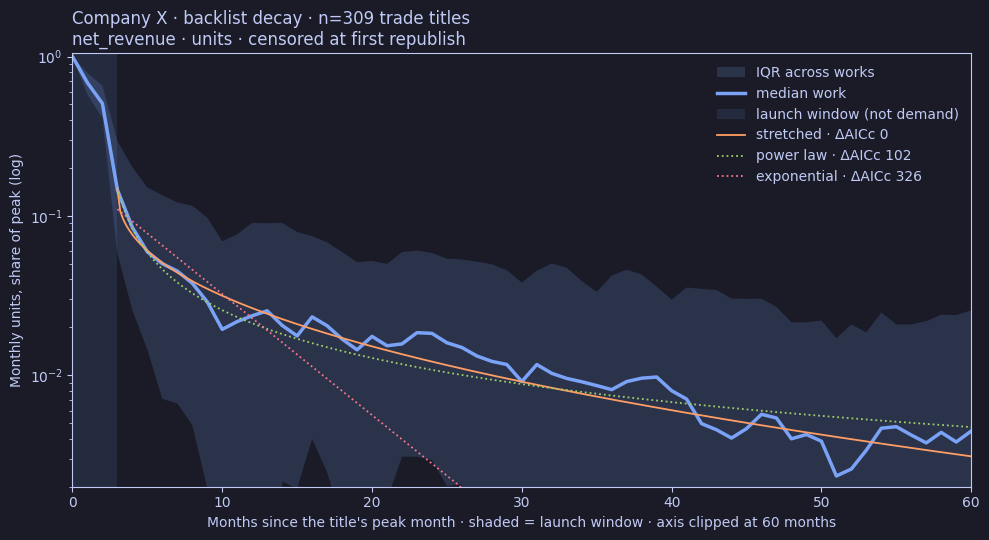

In [18]:
# ── 5.3 Headline figure ──────────────────────────────────────────────────
# Two regimes on one chart: the shaded launch window (channel fill unwinding)
# and the backlist fit that starts where it ends.
X_MAX_HEAD  = 60          # months shown. Just past MIN_OBS_MONTHS (48), so
                          # nearly the whole axis is fully observable. Past
                          # this the sample is survivor-selected.
                          # MODIFY: 36 for a tighter commercial read.
BAND_COLOUR = "#7aa2f7"

fig, ax = plt.subplots(figsize=(10, 5.5))

mc = median_curve.loc[median_curve["t"] <= X_MAX_HEAD]
ax.fill_between(mc["t"], mc["q25"], mc["q75"], alpha=.18, label="IQR across works")
ax.plot(mc["t"], mc["median"], lw=2.5, label="median work")

# Launch window: the smoothing window still contains the peak month here, so
# anything inside this band is stock moving into the channel, not demand.
ax.axvspan(0, BACKLIST_START, color=BAND_COLOUR, alpha=.12, lw=0,
           label="launch window (not demand)")

# Fitted forms, drawn only across the regime they were fitted on (t >= 3),
# and rescaled back onto the peak-normalised axis.
tt = np.linspace(BACKLIST_START, X_MAX_HEAD, 300)
for _, r in res_bl.iterrows():
    ax.plot(tt, r["fn"](tt - BACKLIST_START, *r["popt"]) * mc_bl["median"].iloc[0],
            "-" if r["model"] == res_bl.iloc[0]["model"] else ":", lw=1.3,
            label=f"{r['model']} · ΔAICc {r['dAICc']:.0f}")

# Log scale: the tail is where the question lives, and a linear axis flattens it.
ax.set_yscale("log"); ax.set_ylim(0.002, 1.05)
ax.set_xlim(0, X_MAX_HEAD)
ax.set_xlabel(f"Months since the title's peak month · shaded = launch window · "
              f"axis clipped at {X_MAX_HEAD} months")
ax.set_ylabel("Monthly units, share of peak (log)")
ax.set_title(f"Company X · backlist decay · n={len(cohort)} trade titles\n"
             f"{Q2_KEY} · units · censored at first republish", loc="left")
ax.legend(frameon=False)
save_fig(fig, "d02_headline_decay")
plt.show()

<a id="cases"></a>
## 6. Case studies

The cohort censors each work at its first republish. The case studies do the opposite: they reassemble every edition of a few republished works, so the mechanism the cohort controls for is visible. Titles are shown as `Title A` to `Title E`, with their genre.

In [19]:
# ── 6.1 Work attributes: genre and dominant format ──────────────────────────
def safe_mode(s):
    """Most common non-null value; NA if the group is entirely null.
    Plain .mode().iloc[0] raises IndexError on all-null groups."""
    m = s.dropna().mode()
    return m.iloc[0] if len(m) else pd.NA

work_genre = (sales_q2.groupby("work_key")["genre_std"]
                      .agg(safe_mode).rename("genre_std"))

# `Type` is authoritative over `edition` for format. At work grain a title can
# carry several formats, so take the dominant one by units and flag whether
# the work is format-pure.
fmt = (sales_q2.groupby(["work_key", "Type"], observed=True)["Qty"]
               .sum().reset_index())
tot = fmt.groupby("work_key")["Qty"].sum()
fmt = fmt.loc[fmt["work_key"].isin(tot[tot > 0].index)]   # net-negative out
dom = fmt.loc[fmt.groupby("work_key")["Qty"].idxmax()].set_index("work_key")

work_fmt = pd.DataFrame({
    "type_dominant": dom["Type"],
    "type_pure": (dom["Qty"] / tot.loc[dom.index]) >= 0.95,
})

seg = hl.to_frame().join(work_genre).join(work_fmt)

print(f"Cohort works : {len(seg):,}")
print(f"  missing genre_std : {seg['genre_std'].isna().sum():,}")
print(f"  missing format    : {seg['type_dominant'].isna().sum():,}")

print("\nGENRE MIX, % of cohort works")
print((seg["genre_std"].value_counts(dropna=False, normalize=True) * 100).round(1).to_string())

# `== True` not `~`: type_pure carries nulls, which promote it to float, and
# `~` on a float raises TypeError.
pure = seg.loc[seg["type_pure"] == True]
print("\nFORMAT MIX: format-pure works (>=95% of units in one Type)")
print(pure["type_dominant"].value_counts().to_string())
print(f"  mixed-format works excluded : {(seg['type_pure'] == False).sum():,}")
print("\n→ Format segmentation is NOT viable: the cohort is effectively "
      "single-format at work grain.")

Cohort works : 309
  missing genre_std : 0
  missing format    : 0

GENRE MIX, % of cohort works
genre_std
Fiction        49.5
Non-Fiction    42.1
YP              8.4

FORMAT MIX: format-pure works (>=95% of units in one Type)
type_dominant
Paperback    282
eBook          7
  mixed-format works excluded : 20

→ Format segmentation is NOT viable: the cohort is effectively single-format at work grain.


EDITION ROSTER: each line is one edition reassembled into its case
  Title A: 1 edition(s)
       edition 1  from 2018-01  ·  26,002u
  Title B: 2 edition(s)
       edition 1  from 2011-08  ·  652u
       edition 2  from 2021-09  ·  602u
  Title C: 2 edition(s)
       edition 1  from 2017-06  ·  506u
       edition 2  from 2017-11  ·  731u
  Title D: 2 edition(s)
       edition 1  from 2021-03  ·  796u
       edition 2  from 2023-04  ·  312u
  Title E: 2 edition(s)
       edition 1  from 2017-05  ·  1,176u
       edition 2  from 2017-11  ·  675u

REPUBLISH EVENTS (later-edition first sales, months from peak)
  title   first   t
Title B 2021-09 115
Title C 2017-11   4
Title D 2023-04  25
Title E 2017-11   6


saved → figures/d03_case_studies_log.png


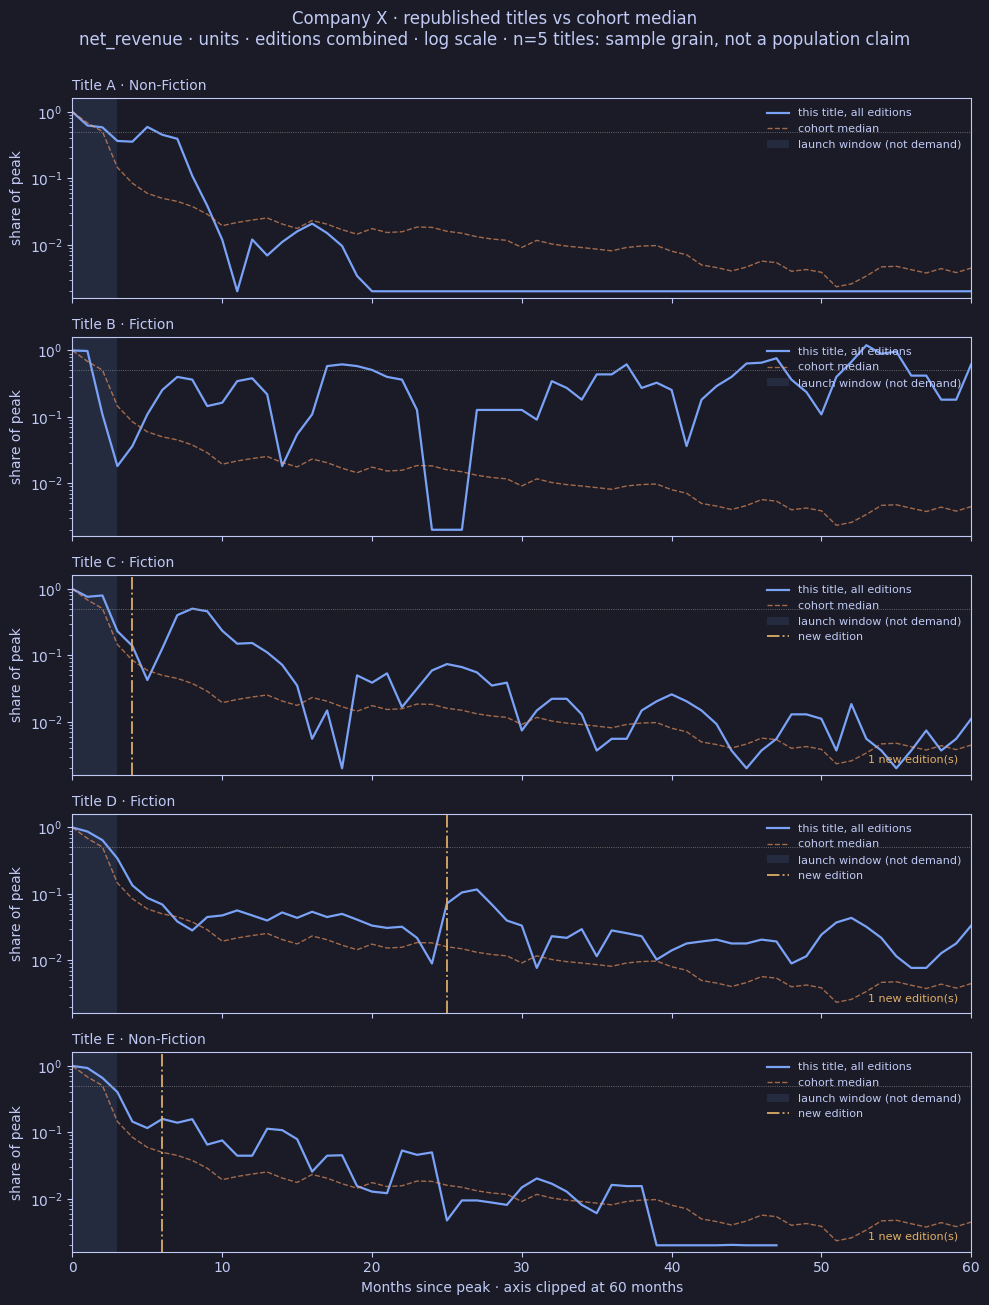

saved → figures/d03_case_studies_linear.png


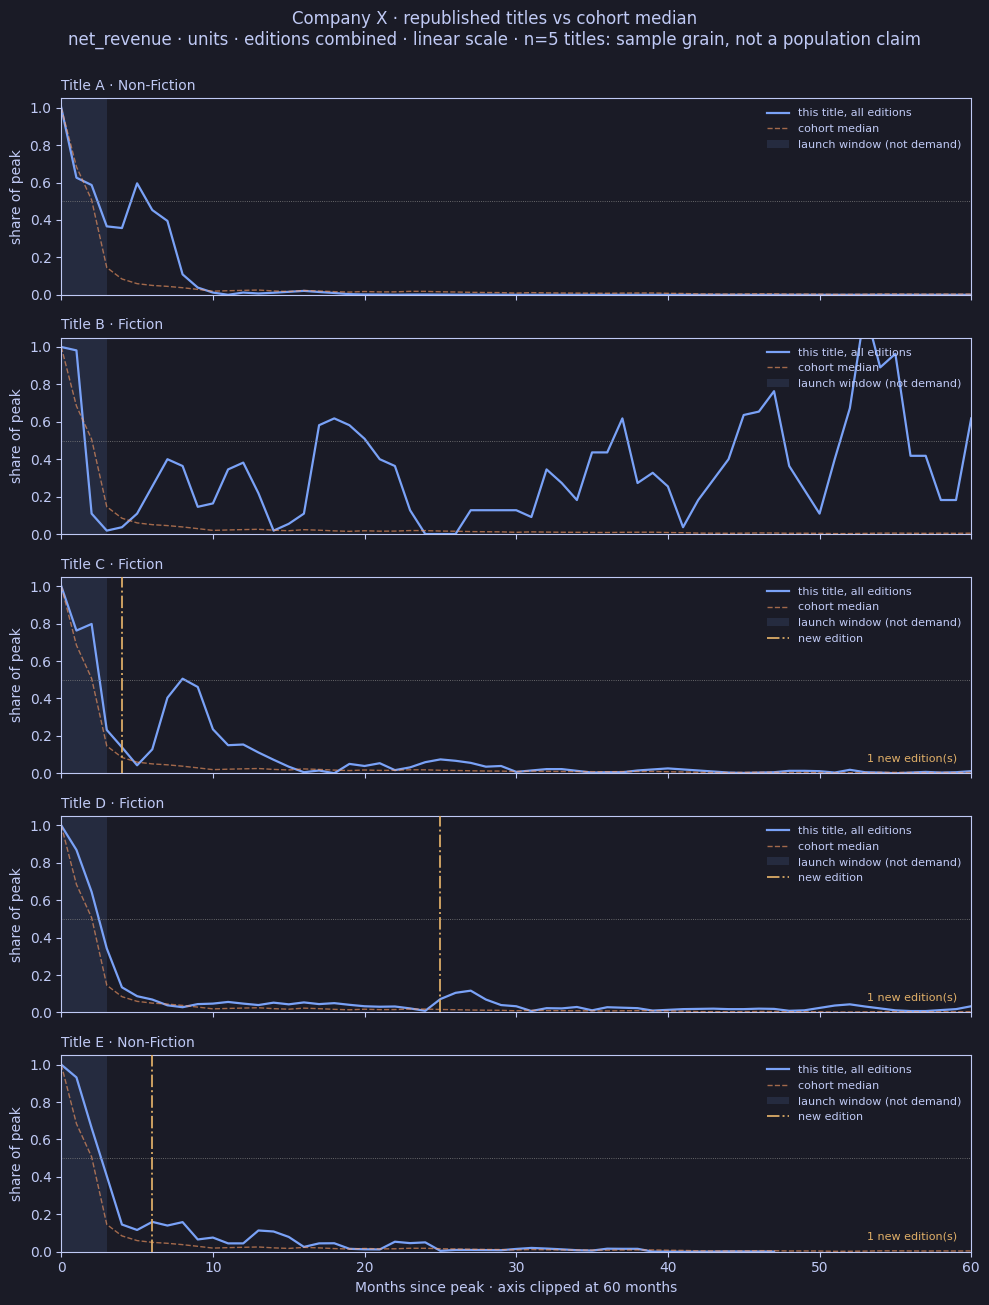

In [20]:
# ── 6.2 Case studies: republished titles against the cohort median ─────────
# GRAIN NOTE: the cohort runs at EDITION grain, because the edition marker sits
# inside the truncated description. That is the conservative choice: a
# republish can never be chained onto a first edition's tail to inflate
# persistence. This panel deliberately reassembles editions into works.
X_MAX       = 60      # months shown; beyond this the sample is survivor-selected
Y_FLOOR     = 0.002   # log scale cannot plot zero; months below draw at the floor
BAND_COLOUR = "#7aa2f7"
REP_COLOUR  = "#e0af68"

# Description prefixes that catch every edition of each case (confidential).
CASE_PREFIXES = CONF["case_prefixes"]

all_keys = sorted(panel_full["work_key"].unique())
groups = {tag: [k for k in all_keys if k.startswith(p)]
          for tag, p in CASE_PREFIXES.items()}
groups = {t: ks for t, ks in groups.items() if ks}

print("EDITION ROSTER: each line is one edition reassembled into its case")
for tag, ks in groups.items():
    print(f"  Title {tag}: {len(ks)} edition(s)")
    for i, k in enumerate(ks, 1):
        first = panel_full.loc[panel_full["work_key"] == k, "ym"].min()
        units = panel_full.loc[panel_full["work_key"] == k, "units"].sum()
        print(f"       edition {i}  from {first}  ·  {units:,.0f}u")

# ── one series per case, peak-aligned ────────────────────────────────────
series, editions = {}, {}
for tag, ks in groups.items():
    sub = panel_full.loc[panel_full["work_key"].isin(ks)]
    tot = sub.groupby("ym")["units"].sum().sort_index()
    idx = pd.period_range(tot.index.min(), tot.index.max(), freq="M")
    tot = tot.reindex(idx, fill_value=0)
    sm  = tot.rolling(PEAK_SMOOTH, min_periods=1).mean()

    launch = idx.min()
    win    = sm.loc[[p for p in idx if (p - launch).n < PEAK_WINDOW]]
    pk_ym, pk_val = win.idxmax(), win.max()
    if pk_val <= 0:
        continue
    series[tag] = pd.DataFrame({
        "t": [(p - pk_ym).n for p in idx],
        "norm": (sm / pk_val).clip(lower=0).values})

    # Republish = each edition's first sale, other than the earliest.
    firsts = sorted((panel_full.loc[panel_full["work_key"] == k, "ym"].min(), k)
                    for k in ks)
    editions[tag] = [{"first": f, "t": (f - pk_ym).n} for f, k in firsts[1:]]

ev_tbl = pd.DataFrame([{"title": f"Title {t}", **e} for t, es in editions.items() for e in es])
print("\nREPUBLISH EVENTS (later-edition first sales, months from peak)")
print("  none detected" if ev_tbl.empty else ev_tbl.to_string(index=False))

def make_label(tag):
    g = seg["genre_std"].get(groups[tag][0])
    return f"Title {tag} · {g}" if pd.notna(g) else f"Title {tag}"

def build_figure(scale: str):
    tags = list(series)
    fig, axes = plt.subplots(len(tags), 1, figsize=(10, 2.6*len(tags)), sharex=True)
    axes = np.atleast_1d(axes)
    clip = (lambda s: s.clip(lower=Y_FLOOR)) if scale == "log" else (lambda s: s)

    for ax, tag in zip(axes, tags):
        g = series[tag].loc[series[tag]["t"].between(0, X_MAX)]
        ax.plot(g["t"], clip(g["norm"]), lw=1.6, label="this title, all editions")

        mc = median_curve.loc[median_curve["t"] <= X_MAX]
        ax.plot(mc["t"], clip(mc["median"]), lw=1, ls="--", alpha=.6,
                label="cohort median")
        ax.axvspan(0, BACKLIST_START, color=BAND_COLOUR, alpha=.12, lw=0,
                   label="launch window (not demand)")

        drawn = 0
        for e in editions.get(tag, []):
            if 0 <= e["t"] <= X_MAX:
                ax.axvline(e["t"], color=REP_COLOUR, lw=1.4, ls="-.", alpha=.9,
                           zorder=5, label="new edition" if drawn == 0 else None)
                drawn += 1
        if drawn:
            ax.text(0.985, 0.06, f"{drawn} new edition(s)", transform=ax.transAxes,
                    ha="right", fontsize=8, color=REP_COLOUR)

        ax.axhline(.5, color="grey", lw=.6, ls=":")
        if scale == "log":
            ax.set_yscale("log"); ax.set_ylim(Y_FLOOR*0.8, 1.6)
        else:
            ax.set_ylim(0, 1.05)
        ax.set_xlim(0, X_MAX)
        ax.set_title(make_label(tag), loc="left", fontsize=10)
        ax.set_ylabel("share of peak")
        ax.legend(frameon=False, fontsize=8, loc="upper right")

    axes[-1].set_xlabel(f"Months since peak · axis clipped at {X_MAX} months")
    fig.suptitle(f"Company X · republished titles vs cohort median\n"
                 f"{Q2_KEY} · units · editions combined · {scale} scale · "
                 f"n={len(tags)} titles: sample grain, not a population claim", y=1.0)
    return fig

for scale in ("log", "linear"):
    fig = build_figure(scale)
    save_fig(fig, f"d03_case_studies_{scale}")
    plt.show()

<a id="conclusion"></a>
## 7. Conclusion

<b>Answering the Research Question</b>
> Books don't die, they slow down. After a sharp launch fall, backlist demand decays at a *decreasing* rate (stretched exponential, β = 0.44) and most titles keep selling for years.

* **The launch and the backlist are two regimes.** Months 0–2 are channel fill unwinding; from month 3 the curve describes demand.
* **Most of a title's life happens after launch.** 62.1% of post-peak units arrive after month 3, and 72.6% of titles still sell in year 5.
* **The tail is intermittent.** Demand becomes sporadic rather than settling on a steady floor, which matters for stock policy: small, occasional reorders rather than a steady run rate.
* **Republishing restarts demand** in the case studies, which is why the cohort is censored at the first new edition.

##### So what?
* Keep backlist titles available and discoverable. For the typical title, the majority of post-peak sales come after the launch window.
* Judge a title's performance on more than its launch months: a fast early fall is the norm, not a signal of failure.

##### Limitations
* Invoices record trade movement, not reading; a returned copy nets out a shipped one.
* `work_key` comes from a hand-typed description truncated at 30 characters; works with no ISBN cannot be anchored.
* Editions enter the cohort as separate works. That is conservative (a republish cannot be chained onto a first edition's tail), but it counts re-launches as new titles. Same-ISBN reprints leave no trace in the register.
* The cohort is 309 of 468 trade titles: 95 peak below 10 units, 79 peak after July 2022 (right-censored) and 7 lack six months of post-peak runway. It therefore skews older than the live catalogue.
* The fit runs on the **median** curve, so it describes the typical title, not total volume, which a few outliers dominate.
* Format segmentation is not viable: 282 paperback against 7 eBook among format-pure works.